In [1]:
import kagglehub
import pandas as pd
import hashlib
import json

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")



print("Path to dataset files:", path)
import os

# 1. Join the directory path with the specific CSV filename
csv_file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Read the CSV file
df = pd.read_csv(csv_file_path)

Path to dataset files: /home/yaponsk/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [2]:
import numpy as np

# index=False -- row *position* carries no content meaning, so it shouldn't affect
# the hash either. XOR-combine the per-row hashes instead of hashing them in
# whatever order the rows happen to arrive in -- XOR is order-independent, so a
# re-shuffled-but-identical CSV (e.g. Kaggle re-exports it in a new row order)
# now produces the SAME hash instead of a false 'drift' warning.
row_hashes = pd.util.hash_pandas_object(df, index=False).values.astype(np.uint64)
df_hash = hashlib.sha256(np.bitwise_xor.reduce(row_hashes).tobytes()).hexdigest()
print(f"Dataset hash: {df_hash}")

if os.path.exists('dataset_baseline.json'):
    with open('dataset_baseline.json') as f:
        baseline_hash = json.load(f)['dataset_hash']
    if df_hash != baseline_hash:
        print(f"⚠️ WARNING: dataset hash changed!\nBaseline: {baseline_hash}\nCurrent:  {df_hash}")
    else:
        print("Dataset hash matches baseline — no drift detected.")
else:
    with open('dataset_baseline.json', 'w') as f:
        json.dump({'dataset_hash': df_hash}, f, indent=2)
    print(f"Baseline dataset hash recorded: {df_hash}")

Dataset hash: e509e674fc08e00ab0cc0b9bdc61fb26128e65c24d272ab9f68a7271c59f043e
Dataset hash matches baseline — no drift detected.


In [3]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve
)

from sklearn.model_selection import RandomizedSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Show each DISTINCT warning once, rather than suppressing everything.
#
# This was a bare filterwarnings('ignore'), which silenced every warning for
# the whole session -- during the one activity where you most want to hear
# about problems. Lifting it revealed ~1,457 warnings from the model-
# comparison cell alone, including: LogisticRegression's `penalty` argument
# is deprecated in scikit-learn 1.8 and REMOVED IN 1.10, so that cell's
# penalty: ['l1','l2'] search will break on upgrade. It was also hiding any
# ConvergenceWarning from that same Logistic Regression -- checked, there
# are none, so its reported ROC-AUC is sound.
#
# 'once' keeps output readable inside a 200-iteration search while leaving
# every distinct problem visible. If a specific warning is investigated and
# accepted, suppress that one by category -- don't restore the catch-all.
warnings.simplefilter('once')

# Set plotting style
sns.set_theme(style="whitegrid")

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
df = df.replace(["?", "", "NA", "nan",' '], np.nan)
df = df.drop('customerid', axis=1)
df.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   str    
 3   dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   str    
 6   multiplelines     7043 non-null   str    
 7   internetservice   7043 non-null   str    
 8   onlinesecurity    7043 non-null   str    
 9   onlinebackup      7043 non-null   str    
 10  deviceprotection  7043 non-null   str    
 11  techsupport       7043 non-null   str    
 12  streamingtv       7043 non-null   str    
 13  streamingmovies   7043 non-null   str    
 14  contract          7043 non-null   str    
 15  paperlessbilling  7043 non-null   str    
 16  paymentmethod     7043 non-null   str    
 17  monthl

In [6]:
df.describe(include='all')

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
count,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032,7043
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6530,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
dupes = df[df.duplicated(keep=False)]
dupes.sort_values(list(df.columns)).head(20)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.2,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.2,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.1,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.1,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [9]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows ({len(df)} remaining)")

Dropped 22 duplicate rows (7021 remaining)


In [10]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')


In [11]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

In [12]:
from feature_engineering_telco import engineer_features

y = df['churn']
X = df.drop(columns=['churn'], inplace=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# engineer_features is applied per-split (not once on the full df) even though
# it's currently stateless — keeps the pattern correct if a future feature
# ever needs .fit() on training data only (e.g. target encoding).
X_train = engineer_features(X_train)
X_test  = engineer_features(X_test)
X_tr    = engineer_features(X_tr) #---------#
X_val   = engineer_features(X_val)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category','string']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2. Bundle pipelines into a single master preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

***visualualization of the baseline models. next 6 cells can be removed later for cosmetic effect and saving computationion time***

In [14]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42))
])

In [15]:
model_pipeline.fit(X_tr, y_tr) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'contractvstenure', 'average_monthly_charges','charge_change_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By sp

        MODEL EVALUATION METRICS          

ROC-AUC Score: 0.8356

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       827
           1       0.62      0.52      0.57       297

    accuracy                           0.79      1124
   macro avg       0.73      0.70      0.71      1124
weighted avg       0.78      0.79      0.78      1124



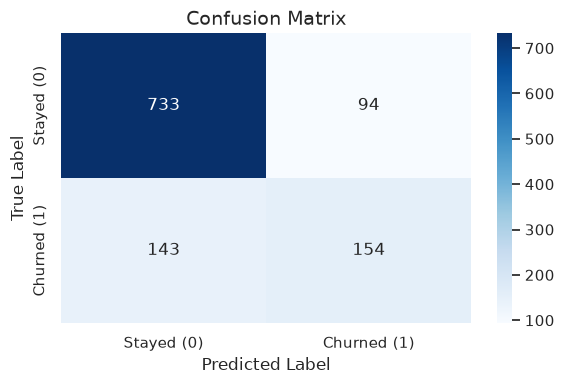

In [16]:
# 1. Generate predictions and probabilities from the test set
y_pred = model_pipeline.predict(X_val)
y_pred_proba = model_pipeline.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_pred_proba)
class_report = classification_report(y_val, y_pred)
conf_matrix = confusion_matrix(y_val, y_pred)

# 3. Print the text reports
print("==========================================")
print("        MODEL EVALUATION METRICS          ")
print("==========================================\n")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(class_report)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
neg_cases = y_tr.value_counts()[0]
pos_cases = y_tr.value_counts()[1]
spw = neg_cases / pos_cases
print(f"Negative Cases: {neg_cases}")
print(f"Positive Cases: {pos_cases}")
print(f"Scale Positives Weight: {spw}")

Negative Cases: 3304
Positive Cases: 1188
Scale Positives Weight: 2.781144781144781


        MODEL EVALUATION METRICS          

ROC-AUC Score: 0.8381

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       827
           1       0.58      0.63      0.60       297

    accuracy                           0.78      1124
   macro avg       0.72      0.73      0.72      1124
weighted avg       0.79      0.78      0.78      1124



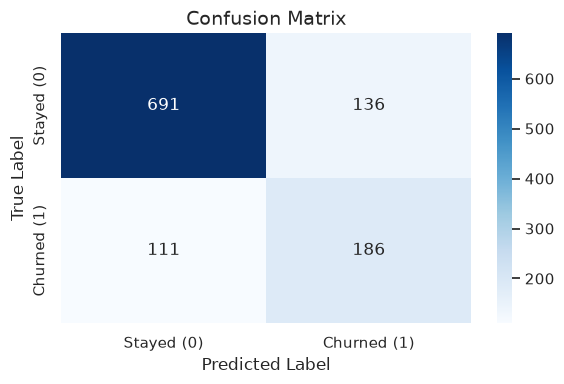

In [18]:
#compare the model with and without spw
model_pipeline_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, scale_pos_weight=spw))
])
model_pipeline_tuned.fit(X_tr, y_tr)
# 1. Generate predictions and probabilities from the test set
y_pred = model_pipeline_tuned.predict(X_val)
y_pred_proba = model_pipeline_tuned.predict_proba(X_val)[:, 1]

# 2. Calculate core metrics
roc_auc = roc_auc_score(y_val, y_pred_proba)
class_report = classification_report(y_val, y_pred)
conf_matrix = confusion_matrix(y_val, y_pred)

# 3. Print the text reports
print("==========================================")
print("        MODEL EVALUATION METRICS          ")
print("==========================================\n")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(class_report)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Churned (1)'], 
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

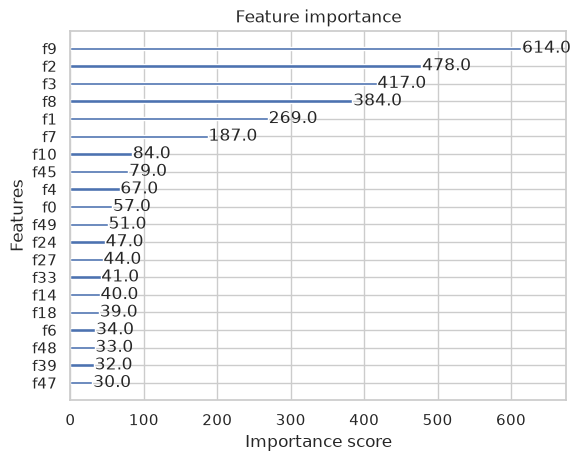

In [19]:
xgb.plot_importance(model_pipeline_tuned.named_steps['classifier'], importance_type='weight', max_num_features=20)
plt.show()
#deal with feature names later, for now just get the feature importance and plot it.

In [20]:
cv_scores = cross_val_score(
    estimator=model_pipeline_tuned,   # full pipeline (preprocessor + XGBoost)
    X=X_train,
    y=y_train,
    cv=cv_strategy,             
    scoring='roc_auc',          # Highly recommended for imbalanced churn data
    n_jobs=3                  
)

# 3. Print the results beautifully
print("--- Cross-Validation Results ---")
print(f"Scores per fold: {cv_scores}")
print(f"Mean ROC-AUC:    {cv_scores.mean():.4f}")
print(f"Standard Dev:    {cv_scores.std():.4f}")
print(f"95% Conf. Range: [{cv_scores.mean() - (2 * cv_scores.std()):.4f} to {cv_scores.mean() + (2 * cv_scores.std()):.4f}]")

--- Cross-Validation Results ---
Scores per fold: [0.8495149  0.80227212 0.80654609 0.8401937  0.80054581]
Mean ROC-AUC:    0.8198
Standard Dev:    0.0207
95% Conf. Range: [0.7783 to 0.8613]


***end of visualizng the baseline***

In [21]:
#hyperparameter tuning 
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
param_distributions = {
    'classifier__n_estimators': randint(50, 150),
    'classifier__max_depth': randint(3, 6),
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__scale_pos_weight': uniform(1.0, spw * 2)
}
# 2. Set up the Randomized Search
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=200,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_tr, y_tr)

# 3. Fit the search on your training data
print("Starting hyperparameter tuning...")

# 4. Extract and print the best results
print("\n--- Tuning Results ---")
print(f"Best ROC-AUC Score on CV: {random_search.best_score_:.4f}")
print("Best Hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Starting hyperparameter tuning...

--- Tuning Results ---
Best ROC-AUC Score on CV: 0.8458
Best Hyperparameters found:
  classifier__colsample_bytree: 0.6606699518931004
  classifier__learning_rate: 0.07234441355910964
  classifier__max_depth: 3
  classifier__min_child_weight: 7
  classifier__n_estimators: 82
  classifier__scale_pos_weight: 1.1865171117289817
  classifier__subsample: 0.8279558739485267


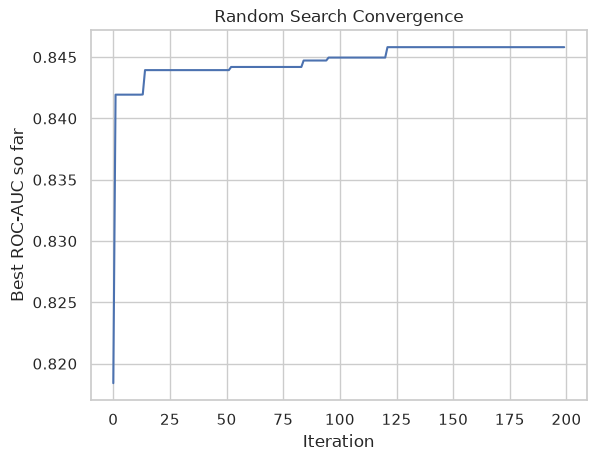

In [22]:
import matplotlib.pyplot as plt

scores = random_search.cv_results_['mean_test_score']
running_best = pd.Series(scores).cummax()

plt.plot(running_best)
plt.xlabel('Iteration')
plt.ylabel('Best ROC-AUC so far')
plt.title('Random Search Convergence')
plt.show()

In [23]:
# # 1. Predict using the best model found during the search
# y_pred = random_search.predict(X_test)
# y_proba = random_search.predict_proba(X_test)[:, 1]

# # 2. Print the final performance report
# print("--- Final Tuned Model Test Performance ---")
# print(classification_report(y_test, y_pred))
# print(f"Tuned Test ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

In [24]:
# 1. Extract the tuned and trained pipeline from the search. basically renamed it to best_tuned_model for clarity
best_tuned_model = random_search.best_estimator_

# 2. Evaluate using Stratified K-Fold Cross Validation on the BEST model
cv_roc_auc = cross_val_score(best_tuned_model, X_train, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
cv_f1 = cross_val_score(best_tuned_model, X_train, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)

print(f"Stratified 5-Fold CV ROC-AUC: {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std():.4f})")
print(f"Stratified 5-Fold CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

# 3. Generate predictions using the best model
y_pred_balanced = best_tuned_model.predict(X_val)
print("\nClassification Report (Balanced):")
print(classification_report(y_val, y_pred_balanced))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_balanced))

Stratified 5-Fold CV ROC-AUC: 0.8491 (+/- 0.0175)
Stratified 5-Fold CV F1-Score: 0.6103 (+/- 0.0213)

Classification Report (Balanced):
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       827
           1       0.68      0.61      0.64       297

    accuracy                           0.82      1124
   macro avg       0.77      0.75      0.76      1124
weighted avg       0.82      0.82      0.82      1124


Confusion Matrix:
[[743  84]
 [117 180]]


In [25]:
# 1. Get UNBIASED (out-of-fold) probability predictions on X_train (X_tr + X_val,
#    80% of the data), via 5-fold CV. Each row's prediction comes from a fold that
#    never trained on it, so these are safe to use for threshold selection even
#    though X_train is also what the FINAL model gets refit on below -- unlike
#    reusing X_val after a refit, there's no leakage here.
best_tuned_model = random_search.best_estimator_
oof_proba = cross_val_predict(
    best_tuned_model, X_train, y_train,
    cv=cv_strategy, method='predict_proba', n_jobs=-1
)[:, 1]

# 2. Coarse threshold scan -- on (y_train, oof_proba)
thresholds = np.arange(0.0, 1.0, 0.05)
threshold_results = []

for thresh in thresholds:  #--------#
    y_pred_thresh = (oof_proba >= thresh).astype(int)
    precision = precision_score(y_train, y_pred_thresh, pos_label=1, zero_division=0)
    recall = recall_score(y_train, y_pred_thresh, pos_label=1)
    f1 = f1_score(y_train, y_pred_thresh, pos_label=1)
    false_positives = ((y_pred_thresh == 1) & (y_train == 0)).sum()
    false_negatives = ((y_pred_thresh == 0) & (y_train == 1)).sum()
    threshold_results.append({
        'Threshold': thresh, 'Precision (Confidence)': round(precision, 3),
        'Recall (Catch Rate)': round(recall, 3), 'F1-Score': round(f1, 3),
        'False Alarms (FP)': false_positives, 'Missed Churners (FN)': false_negatives
    })

df_thresholds = pd.DataFrame(threshold_results)






# --- Business assumptions behind the profit formula ---
# These three constants convert a probability threshold into a dollar figure.
# They're illustrative assumptions for this project, not numbers pulled from
# real finance/marketing data -- flagging that explicitly rather than letting
# them look empirically derived.

# CLV: estimated $ value of successfully retaining this customer. Rough
# proxy = avg monthly charge * expected extra months of retention a
# successful save buys (e.g. ~$70/mo * ~3 months ~= $200).
clv = 200

# Cost applied to every customer TARGETED by the campaign, whether or not
# the retention offer works (e.g. a discount/incentive, or agent outreach
# time) -- not just the successes.
cost = 20

# Fraction of TARGETED churners actually retained by the campaign (not
# 100% -- some churn anyway despite the outreach). Treated here as a
# placeholder assumption; replace with real historical campaign conversion
# data if this were deployed.
success_rate = 0.3

#--------#


total_actual_churners = y_train.sum()
df_thresholds['True Positives (TP)'] = total_actual_churners - df_thresholds['Missed Churners (FN)']
df_thresholds['Campaign Profit ($)'] = (
    (df_thresholds['True Positives (TP)'] * success_rate * clv) -
    ((df_thresholds['True Positives (TP)'] + df_thresholds['False Alarms (FP)']) * cost)
)#----------------#

# Full coarse-grid table: precision/recall/F1 alongside FP/FN/TP/profit for every threshold checked
coarse_table = df_thresholds.sort_values(by='Campaign Profit ($)', ascending=False).reset_index(drop=True)
print("=== Coarse-Grid Threshold Scan (5-fold OOF predictions on X_train) ===")
print(coarse_table.to_string(index=False))

best_coarse_threshold = coarse_table.iloc[0]['Threshold']
print(f"\nCoarse-grid best threshold (5-fold OOF on X_train): {best_coarse_threshold:.2f}")

# 3. Fine-grained scan, same OOF predictions
fine_low = max(0.0, round(best_coarse_threshold - 0.05, 2))
fine_high = min(1.0, round(best_coarse_threshold + 0.05, 2))
thresholds = np.arange(fine_low, fine_high, 0.01)

threshold_results = []
for thresh in thresholds:
    y_pred_thresh = (oof_proba >= thresh).astype(int)
    precision = precision_score(y_train, y_pred_thresh, pos_label=1, zero_division=0)
    recall = recall_score(y_train, y_pred_thresh, pos_label=1)
    f1 = f1_score(y_train, y_pred_thresh, pos_label=1)
    false_positives = ((y_pred_thresh == 1) & (y_train == 0)).sum()
    false_negatives = ((y_pred_thresh == 0) & (y_train == 1)).sum()
    threshold_results.append({
        'Threshold': thresh, 'Precision (Confidence)': round(precision, 3),
        'Recall (Catch Rate)': round(recall, 3), 'F1-Score': round(f1, 3),
        'False Alarms (FP)': false_positives, 'Missed Churners (FN)': false_negatives
    })

df_thresholds_fine = pd.DataFrame(threshold_results)
df_thresholds_fine['True Positives (TP)'] = total_actual_churners - df_thresholds_fine['Missed Churners (FN)']
df_thresholds_fine['Campaign Profit ($)'] = (
    (df_thresholds_fine['True Positives (TP)'] * success_rate * clv) -
    ((df_thresholds_fine['True Positives (TP)'] + df_thresholds_fine['False Alarms (FP)']) * cost)
)

# Full fine-grid table
fine_table = df_thresholds_fine.sort_values(by='Campaign Profit ($)', ascending=False).reset_index(drop=True)
print("\n=== Fine-Grid Threshold Scan (5-fold OOF predictions on X_train) ===")
print(fine_table.to_string(index=False))

FINAL_THRESHOLD = fine_table.iloc[0]['Threshold']
print(f"\nChosen operating threshold (selected via 5-fold OOF predictions on X_train): {FINAL_THRESHOLD:.2f}")

# 4. FINAL_THRESHOLD came from out-of-fold predictions, never from an in-sample
#    fit -- so it's now safe to refit the final model on ALL of X_train (100% of
#    the 80% split, vs. the 64% X_tr alone) before scoring the untouched test set.
best_tuned_model.fit(X_train, y_train)
y_proba = best_tuned_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba >= FINAL_THRESHOLD).astype(int)

print("\n--- Final held-out test performance at chosen threshold ---")
print(classification_report(y_test, y_pred_final))

=== Coarse-Grid Threshold Scan (5-fold OOF predictions on X_train) ===
 Threshold  Precision (Confidence)  Recall (Catch Rate)  F1-Score  False Alarms (FP)  Missed Churners (FN)  True Positives (TP)  Campaign Profit ($)
      0.40                   0.582                0.700     0.636                748                   445                 1040              26640.0
      0.45                   0.614                0.649     0.631                605                   521                  964              26460.0
      0.35                   0.548                0.756     0.635                925                   363                 1122              26380.0
      0.30                   0.521                0.804     0.632               1097                   291                 1194              25820.0
      0.50                   0.647                0.578     0.610                469                   627                  858              24940.0
      0.25                   0.492 

In [26]:
# --- Sensitivity sweep: how much does the chosen threshold move if our
# business assumptions (CLV, cost, success_rate) are wrong? ---

def best_threshold_for(clv_, cost_, success_rate_, proba, y_true, thresholds=np.arange(0.05, 0.96, 0.01)):
    """Returns (best_threshold, best_profit) for one (clv, cost, success_rate) combo."""
    best_thresh, best_profit = None, -np.inf
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        tp = y_true.sum() - fn
        profit = (tp * success_rate_ * clv_) - ((tp + fp) * cost_)
        if profit > best_profit:
            best_thresh, best_profit = t, profit
    return best_thresh, best_profit


# Sweep each assumption independently, +/- 25% and +/-50% around your
# original values (clv=200, cost=20, success_rate=0.3), holding the other
# two fixed at their original value.
base = {"clv": 200, "cost": 20, "success_rate": 0.3}
sweep_rows = []

for param, base_val in base.items():
    for pct_change in [-0.5, -0.25, 0, 0.25, 0.5]:
        params = dict(base)
        params[param] = base_val * (1 + pct_change)
        thresh, profit = best_threshold_for(params["clv"], params["cost"], params["success_rate"], oof_proba, y_train)
        sweep_rows.append({
            "Varied Param": param,
            "% Change": f"{pct_change:+.0%}",
            "Value": round(params[param], 2),
            "Best Threshold": thresh,
            "Profit at Best Threshold ($)": round(profit, 0)
        })

sensitivity_table = pd.DataFrame(sweep_rows)
print("=== Threshold Sensitivity to Business Assumptions (5-fold OOF predictions on X_train) ===")
print(sensitivity_table.to_string(index=False))

=== Threshold Sensitivity to Business Assumptions (5-fold OOF predictions on X_train) ===
Varied Param % Change  Value  Best Threshold  Profit at Best Threshold ($)
         clv     -50% 100.00            0.75                        1720.0
         clv     -25% 150.00            0.47                       12255.0
         clv      +0% 200.00            0.40                       26640.0
         clv     +25% 250.00            0.29                       44280.0
         clv     +50% 300.00            0.27                       62840.0
        cost     -50%  10.00            0.21                       50420.0
        cost     -25%  15.00            0.27                       37785.0
        cost      +0%  20.00            0.40                       26640.0
        cost     +25%  25.00            0.46                       18880.0
        cost     +50%  30.00            0.53                       12180.0
success_rate     -50%   0.15            0.75                        1720.0
success_ra

In [27]:
# 5. Compute the same score/profit breakdown on the TEST set, at the single
#    locked-in FINAL_THRESHOLD -- for direct comparison against the OOF
#    table above. This is the first and only time X_test factors into any
#    profit number.
y_pred_test_final = (y_proba >= FINAL_THRESHOLD).astype(int)

precision_test = precision_score(y_test, y_pred_test_final, pos_label=1, zero_division=0)
recall_test = recall_score(y_test, y_pred_test_final, pos_label=1)
f1_test = f1_score(y_test, y_pred_test_final, pos_label=1)
false_positives_test = ((y_pred_test_final == 1) & (y_test == 0)).sum()
false_negatives_test = ((y_pred_test_final == 0) & (y_test == 1)).sum()
total_actual_churners_test = y_test.sum()
true_positives_test = total_actual_churners_test - false_negatives_test

profit_test = (
    (true_positives_test * success_rate * clv) -
    ((true_positives_test + false_positives_test) * cost)
)

test_result_table = pd.DataFrame([{
    'Dataset': 'X_test (held-out, first touch)',
    'Threshold': FINAL_THRESHOLD,
    'Precision (Confidence)': round(precision_test, 3),
    'Recall (Catch Rate)': round(recall_test, 3),
    'F1-Score': round(f1_test, 3),
    'False Alarms (FP)': false_positives_test,
    'Missed Churners (FN)': false_negatives_test,
    'True Positives (TP)': true_positives_test,
    'Campaign Profit ($)': profit_test
}])

# Pull the matching row from the OOF fine-grid scan for side-by-side comparison
oof_row = fine_table[fine_table['Threshold'] == FINAL_THRESHOLD].iloc[0]
oof_result_table = pd.DataFrame([{
    'Dataset': 'X_train OOF (used to pick threshold)',
    'Threshold': oof_row['Threshold'],
    'Precision (Confidence)': oof_row['Precision (Confidence)'],
    'Recall (Catch Rate)': oof_row['Recall (Catch Rate)'],
    'F1-Score': oof_row['F1-Score'],
    'False Alarms (FP)': oof_row['False Alarms (FP)'],
    'Missed Churners (FN)': oof_row['Missed Churners (FN)'],
    'True Positives (TP)': oof_row['True Positives (TP)'],
    'Campaign Profit ($)': oof_row['Campaign Profit ($)']
}])

comparison_table = pd.concat([oof_result_table, test_result_table], ignore_index=True)
print("\n=== Train (OOF) vs. Held-Out Test Comparison (same FINAL_THRESHOLD) ===")
print(comparison_table.to_string(index=False))

print("\n--- Final held-out test performance at chosen threshold ---")
print(classification_report(y_test, y_pred_test_final))


=== Train (OOF) vs. Held-Out Test Comparison (same FINAL_THRESHOLD) ===
                             Dataset  Threshold  Precision (Confidence)  Recall (Catch Rate)  F1-Score  False Alarms (FP)  Missed Churners (FN)  True Positives (TP)  Campaign Profit ($)
X_train OOF (used to pick threshold)        0.4                   0.582                0.700     0.636              748.0                 445.0               1040.0              26640.0
      X_test (held-out, first touch)        0.4                   0.589                0.688     0.634              179.0                 116.0                256.0               6660.0

--- Final held-out test performance at chosen threshold ---
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1033
           1       0.59      0.69      0.63       372

    accuracy                           0.79      1405
   macro avg       0.73      0.76      0.74      1405
weighted avg       0.80      0.79   

In [28]:
final_conf_matrix = confusion_matrix(y_test, y_pred_test_final)
final_roc_auc = roc_auc_score(y_test, y_proba)
print(f'chosen threshold: {FINAL_THRESHOLD:.4f}')
print("=== Final Model — Held-Out Test Performance (best_tuned_model @ FINAL_THRESHOLD) ===")
print(f"ROC-AUC: {final_roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_test_final))
print("Confusion Matrix:")
print(final_conf_matrix)

chosen threshold: 0.4000
=== Final Model — Held-Out Test Performance (best_tuned_model @ FINAL_THRESHOLD) ===
ROC-AUC: 0.8441

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1033
           1       0.59      0.69      0.63       372

    accuracy                           0.79      1405
   macro avg       0.73      0.76      0.74      1405
weighted avg       0.80      0.79      0.79      1405

Confusion Matrix:
[[854 179]
 [116 256]]


### Advanced Evaluation Metrics

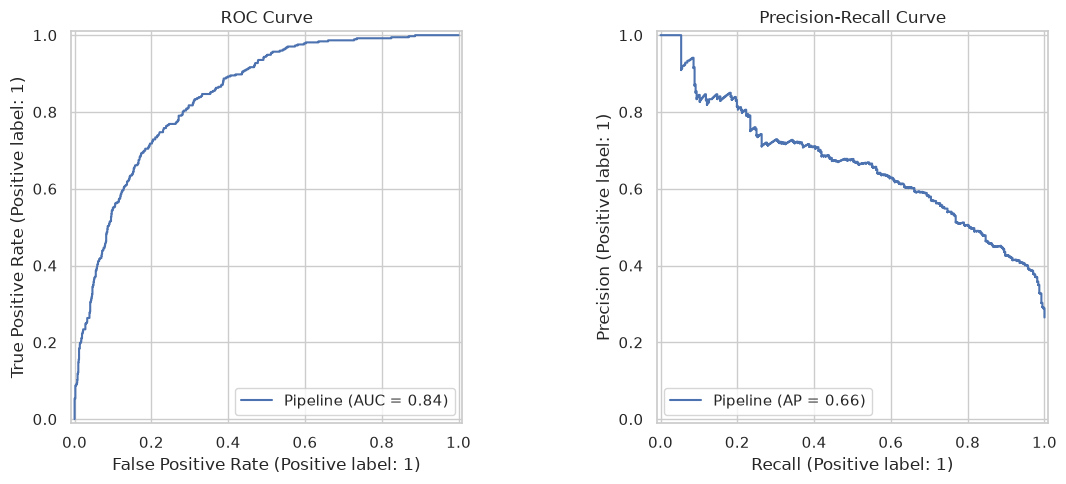

In [29]:

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
RocCurveDisplay.from_estimator(best_tuned_model, X_test, y_test, ax=ax1)
ax1.set_title("ROC Curve")

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(best_tuned_model, X_test, y_test, ax=ax2)
ax2.set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


### Model Comparison

In [30]:
comparison_results = []
search_spaces = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=1000, class_weight='balanced'),
        'params': {
            'classifier__C': uniform(0.01, 10),
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__n_estimators': randint(100, 400),
            'classifier__max_depth': randint(3, 20),
            'classifier__min_samples_split': randint(2, 20),
            'classifier__min_samples_leaf': randint(1, 10),
            'classifier__max_features': ['sqrt', 'log2', None]
        }
    }
}
for name, spec in search_spaces.items():
    temp_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', spec['estimator'])
    ])

    search = RandomizedSearchCV(
        estimator=temp_pipe,
        param_distributions=spec['params'],
        n_iter=200,                # same budget as the XGBoost search
        scoring='roc_auc',
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1
    )
    print(f"Tuning {name}...")
    search.fit(X_tr, y_tr)   # <-- was X_train, y_train; now matches the data slice XGBoost's search used

    # --- Profit + accuracy, on the SAME basis as XGBoost's own threshold
    # selection above: 5-fold OOF predictions on X_train (never in-sample),
    # scanned for the profit-maximizing threshold using the same clv/cost/
    # success_rate constants and formula already defined earlier. Scoring
    # at a fixed 0.5 instead would be faster but would contradict the whole
    # point of this project -- 0.5 isn't a threshold anyone chose on purpose.
    model_oof_proba = cross_val_predict(
        search.best_estimator_, X_train, y_train,
        cv=cv_strategy, method='predict_proba', n_jobs=-1
    )[:, 1]

    scan_thresholds = np.arange(0.05, 0.95, 0.01)
    best_profit, best_thresh, best_acc = -np.inf, None, None
    for t in scan_thresholds:
        pred = (model_oof_proba >= t).astype(int)
        tp = ((pred == 1) & (y_train == 1)).sum()
        fp = ((pred == 1) & (y_train == 0)).sum()
        profit = (tp * success_rate * clv) - ((tp + fp) * cost)
        if profit > best_profit:
            best_profit = profit
            best_thresh = t
            best_acc = (pred == y_train).mean()

    comparison_results.append({
        'Model': name,
        'Mean ROC-AUC': search.best_score_,
        'Std Dev': search.cv_results_['std_test_score'][search.best_index_],
        'Best Threshold': round(best_thresh, 2),
        'Accuracy @ Threshold': round(best_acc, 4),
        'Profit @ Threshold ($)': best_profit
    })

# XGBoost's ROC-AUC comes from the search you already ran on X_tr/y_tr -- no
# need to redo it. Its profit/accuracy reuse oof_proba and FINAL_THRESHOLD
# from the threshold-selection cell above, rather than recomputing them --
# guarantees this row can't drift from the numbers already reported earlier
# in the notebook (and the Results table in the README).
xgb_pred_at_threshold = (oof_proba >= FINAL_THRESHOLD).astype(int)
xgb_accuracy = (xgb_pred_at_threshold == y_train).mean()
xgb_tp = ((xgb_pred_at_threshold == 1) & (y_train == 1)).sum()
xgb_fp = ((xgb_pred_at_threshold == 1) & (y_train == 0)).sum()
xgb_profit = (xgb_tp * success_rate * clv) - ((xgb_tp + xgb_fp) * cost)

comparison_results.append({
    'Model': 'XGBoost (Tuned)',
    'Mean ROC-AUC': random_search.best_score_,
    'Std Dev': random_search.cv_results_['std_test_score'][random_search.best_index_],
    'Best Threshold': round(FINAL_THRESHOLD, 2),
    'Accuracy @ Threshold': round(xgb_accuracy, 4),
    'Profit @ Threshold ($)': xgb_profit
})

df_compare = pd.DataFrame(comparison_results).sort_values(by='Mean ROC-AUC', ascending=False)
print("--- Model Comparison (all models tuned on the same X_tr/y_tr slice; profit/accuracy on 5-fold OOF over X_train) ---")
print(df_compare)

Tuning Logistic Regression...
Tuning Random Forest...
--- Model Comparison (all models tuned on the same X_tr/y_tr slice; profit/accuracy on 5-fold OOF over X_train) ---
                 Model  Mean ROC-AUC   Std Dev  Best Threshold  \
2      XGBoost (Tuned)      0.845812  0.019575            0.40   
1        Random Forest      0.844126  0.016803            0.58   
0  Logistic Regression      0.843892  0.018879            0.58   

   Accuracy @ Threshold  Profit @ Threshold ($)  
2                0.7876                 26640.0  
1                0.7810                 27000.0  
0                0.7758                 26200.0  


"""***i should decide whether stacking might give a small increase (0.002-0.008)%5%) or not after comparing the individual probabilities not the roc auc and stddev***"""

### SHAP Dependence Analysis

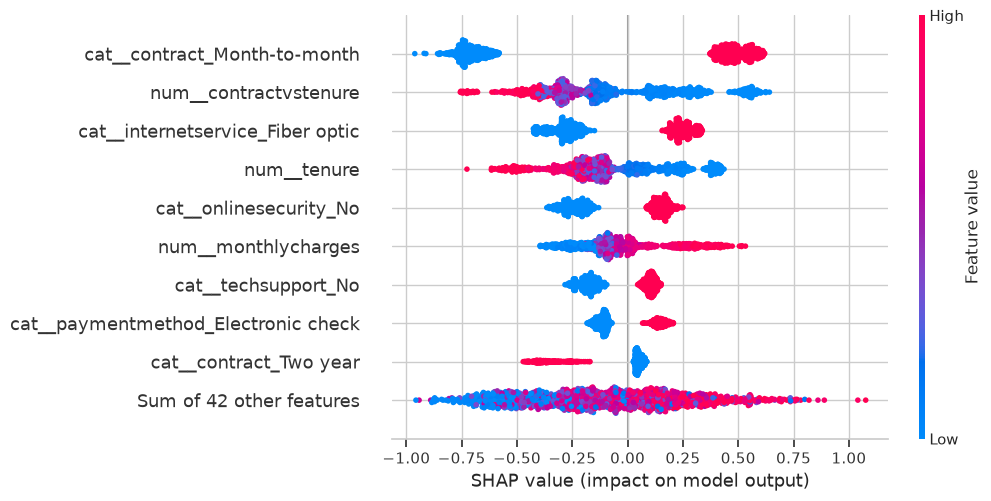

In [31]:
#    1. Transform the raw X_test using the preprocessor from your tuned model
import shap


X_test_transformed = best_tuned_model.named_steps['preprocessor'].transform(X_test)

# 2. Extract feature names from the tuned preprocessor
feature_names = best_tuned_model.named_steps['preprocessor'].get_feature_names_out()

# 3. Create the SHAP explainer targeting the tuned XGBoost classifier
explainer = shap.TreeExplainer(best_tuned_model.named_steps['classifier'])

# 4. Calculate SHAP values
shappies = explainer(X_test_transformed)
shappies.feature_names = feature_names

# 5. Generate the global beeswarm plot
shap.plots.beeswarm(shappies)

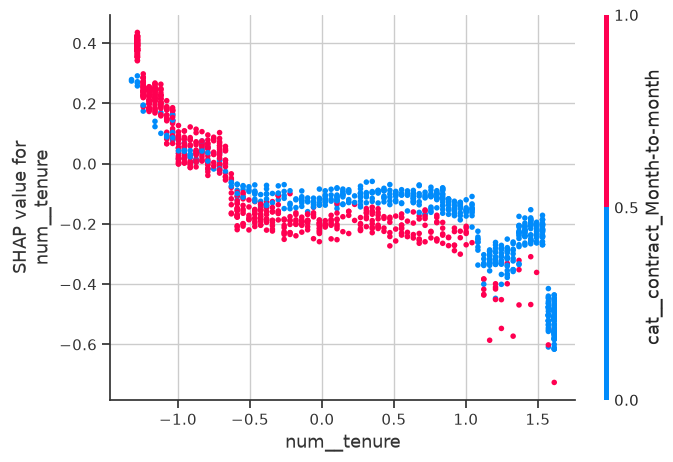

In [32]:
# SHAP Dependence Plot for the most important feature (e.g., tenure)
tenure_feature = "num__tenure"
assert tenure_feature in feature_names, f"{tenure_feature} not found in feature_names"

shap.dependence_plot(
    tenure_feature,
    shappies.values,
    X_test_transformed,
    feature_names=feature_names
)

In [33]:
import joblib
import json
import subprocess
import sklearn
import xgboost
from datetime import datetime, timezone

from config import DUMMY_CUSTOMER


def get_git_commit():
    """Best-effort git commit hash for reproducibility. Returns None if this
    isn't a git repo (e.g. a fresh clone before `git init`, or a zipped
    download) rather than failing the whole cell."""
    try:
        return subprocess.check_output(
            ['git', 'rev-parse', 'HEAD'], stderr=subprocess.DEVNULL
        ).decode('utf-8').strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


joblib.dump(best_tuned_model, 'xgboost_churn_pipeline.pkl')

with open('model_metadata.json', 'w') as f:
    json.dump({
        'threshold': float(FINAL_THRESHOLD),
        'model': 'XGBoost (Tuned)',
        'cv_roc_auc_mean': float(cv_roc_auc.mean()),
        'cv_roc_auc_std': float(cv_roc_auc.std()),
        'trained_at': datetime.now(timezone.utc).isoformat(),
        'git_commit': get_git_commit(),
        'feature_schema_version': '1.0',
        'hash': df_hash,
        # Exact library versions that produced this pickle. joblib/pickle
        # ties a Pipeline's serialized state to the exact scikit-learn/
        # XGBoost version that created it -- neither project guarantees
        # pickle compatibility across releases. config.validate_environment_
        # versions() compares this against the runtime environment at API/
        # batch-script startup and WARNS on a mismatch -- it does not block
        # startup; a hard gate on this belongs in CI, not the live service.
        'library_versions': {
            'scikit-learn': sklearn.__version__,
            'xgboost': xgboost.__version__,
            'numpy': np.__version__,
            'pandas': pd.__version__,
        },
        # Raw, pre-feature-engineering columns the pipeline's preprocessor
        # expects on the input side -- lets a caller (or a future you)
        # confirm at a glance whether this model matches the current
        # feature_engineering_telco.py contract.
        'feature_columns': X_train.columns.tolist(),
        # Probability this exact pickle assigns to config.DUMMY_CUSTOMER.
        # Recorded here so tests/test_artifact.py can pin the artifact's
        # behaviour without the expected value being hand-maintained: a
        # retrain rewrites both the pickle and this number together, so the
        # canary can only fail when the pickle and the environment disagree
        # -- a corrupted artifact, or a library version that unpickles
        # cleanly but predicts differently. That silent-behaviour-change
        # case is exactly what verify_version_check.sh says it cannot check.
        'dummy_customer_score': float(
            best_tuned_model.predict_proba(
                engineer_features(pd.DataFrame([DUMMY_CUSTOMER]))
            )[:, 1][0]
        ),
    }, f, indent=2)

X_test.sample(50, random_state=42).to_csv('simulated_new_customers.csv', index=False)

In [34]:
assert set(X_train.columns) == set(engineer_features(X_test.iloc[:1]).columns), \
    "X_train columns and a fresh engineer_features() call disagree — investigate before saving."

In [35]:
import json
with open('model_metadata.json') as f:
    meta = json.load(f)
print(f"threshold: {meta['threshold']:.3f}")
print(f"feature columns: {meta['feature_columns']}")

threshold: 0.400
feature columns: ['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'total_services', 'is_auto_pay', 'family_tie', 'contractvstenure', 'average_monthly_charges', 'charge_change_ratio']
